# Install R packages

In [ ]:
!pip install rpy2 --quiet

# Enable R

In [ ]:
%load_ext rpy2.ipython

# Load R libraries

In [ ]:
%%R

install.packages("ggplot2")
install.packages("dplyr")
install.packages("lubridate")

library(ggplot2)
library(dplyr)
library(lubridate)

print("Libraries loaded")

[1] "Libraries loaded"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.2.tar.gz'
Content type 'application/x-gzip' length 6358661 bytes (6.1 MB)
downloaded 6.1 MB


The downloaded source packages are in
	‘/tmp/RtmpRx4uma/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.0.tar.gz'
Content type 'application/x-gzip' length 922393 bytes (900 KB)
downloaded 900 KB


The downloaded source packages are in
	‘/tmp/RtmpRx4uma/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/lubridate_1.9.5.tar.gz'
Content type 'application/x-gzip' length 429855 bytes (419 KB)
downloaded 419 KB


The downloaded source packages are in
	‘/tmp/RtmpRx4uma/downloaded_packages’

Attaching package: ‘dplyr’

The following objects are maske

# Upload datasets

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Load datasets

In [ ]:
%%R

app_event <- read.csv("app_events.csv")
complaint <- read.csv("complaints.csv")
customer <- read.csv("customers.csv")
drivers <- read.csv("drivers.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
orders <- read.csv("orders.csv")
vehicle <- read.csv("vehicles.csv")

print("Datasets loaded in R")

[1] "Datasets loaded in R"


# Analysis 1 – Distribution of order value

Business problem

Understand revenue distribution and detect unusually high or low values.

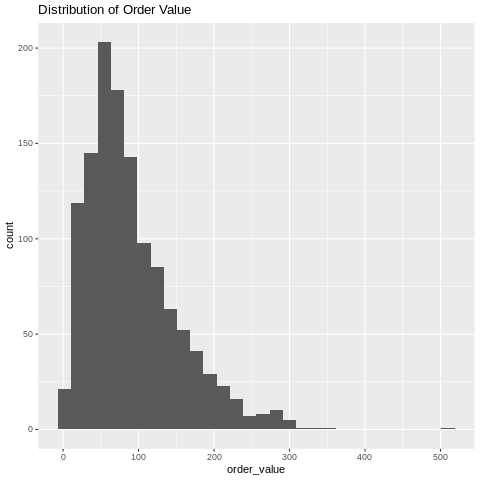

In [ ]:
%%R
summary(orders$order_value)

ggplot(orders, aes(x = order_value)) +
geom_histogram(bins = 30) +
ggtitle("Distribution of Order Value")

# Analysis 2 – Orders by service type

Business problem

Compare demand across Passenger, Parcel, Retail services.

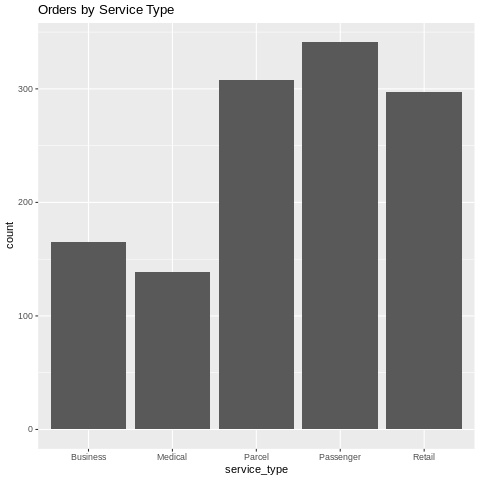

In [ ]:
%%R

orders %>%
group_by(service_type) %>%
summarise(total_orders = n(),
avg_value = mean(order_value))

ggplot(orders, aes(service_type)) +
geom_bar() +
ggtitle("Orders by Service Type")

# Analysis 3 – Customer loyalty vs engagement correlation

Business problem

Check relationship between loyalty score and engagement score.


(`geom_point()`). 



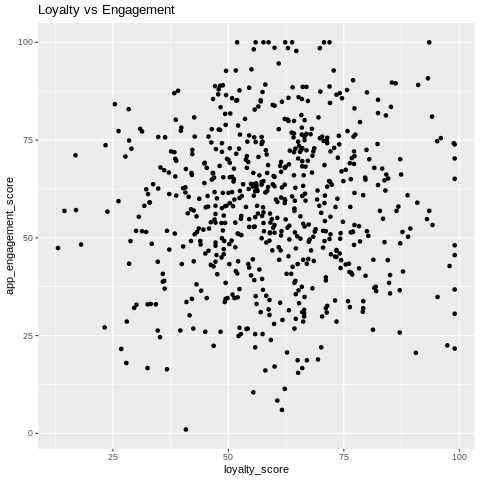

In [ ]:
%%R

cor(customer$loyalty_score,
customer$app_engagement_score,
use="complete.obs")

ggplot(customer,
aes(loyalty_score, app_engagement_score)) +
geom_point() +
ggtitle("Loyalty vs Engagement")

# Analysis 4 – Complaints by severity

Business problem

Understand seriousness of customer dissatisfaction.

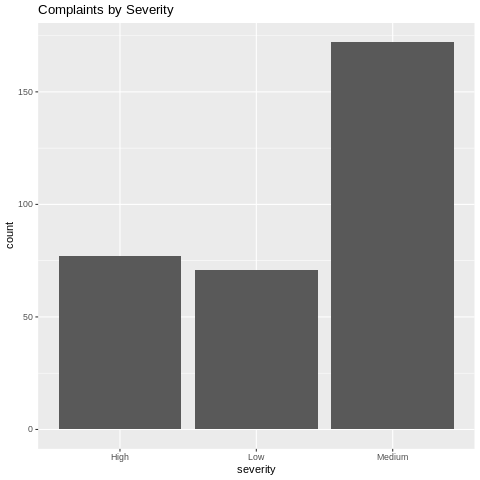

In [ ]:
%%R

complaint %>%
group_by(severity) %>%
summarise(total = n(),
avg_resolution = mean(resolution_days))

ggplot(complaint, aes(severity)) +
geom_bar() +
ggtitle("Complaints by Severity")

# Analysis 5 – Driver rating distribution

Business problem

Evaluate workforce service quality.

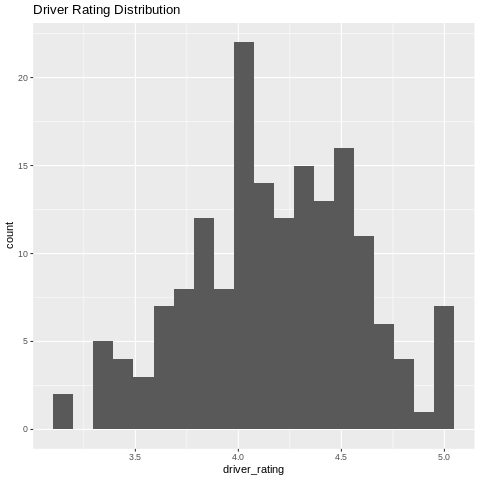

In [ ]:
%%R

summary(drivers$driver_rating)

ggplot(drivers,
aes(driver_rating)) +
geom_histogram(bins=20) +
ggtitle("Driver Rating Distribution")

# Analysis 6 – Training score vs driver rating

Business problem

Determine whether training influences driver performance.


(`geom_point()`). 



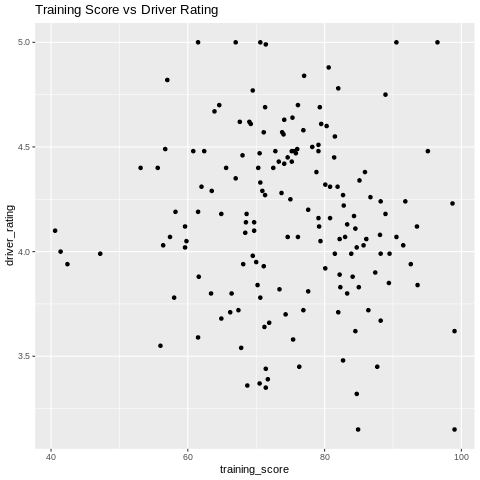

In [ ]:
%%R

cor(drivers$training_score,
drivers$driver_rating)

ggplot(drivers,
aes(training_score, driver_rating)) +
geom_point() +
ggtitle("Training Score vs Driver Rating")

# Analysis 7 – Vehicle battery health analysis

Business problem

Check fleet reliability risk.

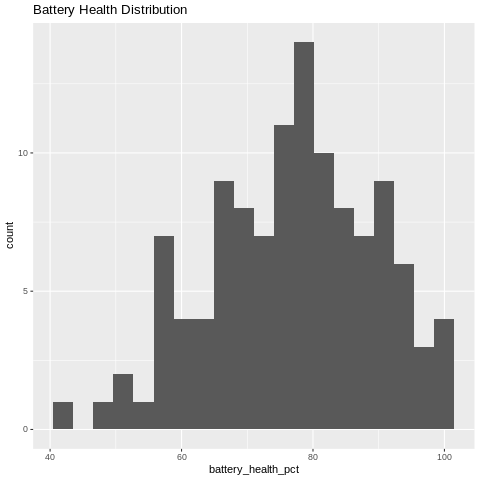

In [ ]:
%%R

summary(vehicle$battery_health_pct)

ggplot(vehicle,
aes(battery_health_pct)) +
geom_histogram(bins=20) +
ggtitle("Battery Health Distribution")

# Analysis 8 – Incident resolution time

Business problem

Evaluate operational disruption handling efficiency.

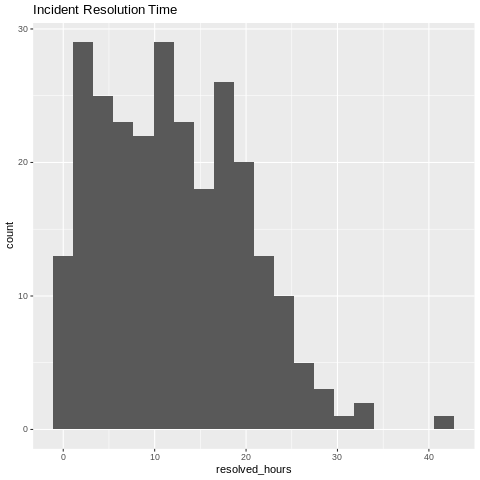

In [ ]:
%%R

summary(incidents$resolved_hours)

ggplot(incidents,
aes(resolved_hours)) +
geom_histogram(bins=20) +
ggtitle("Incident Resolution Time")

# Analysis 9 – App latency performance

Business problem

Check technical performance of mobile platform.

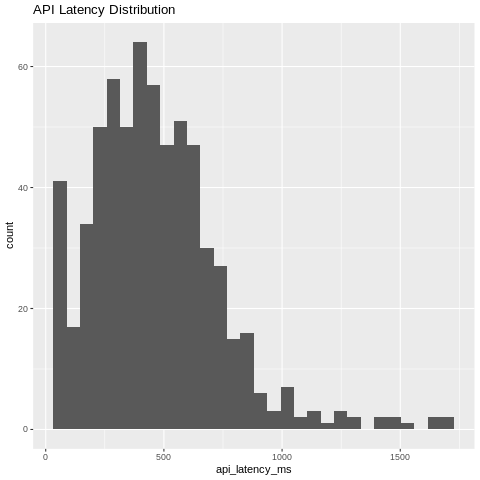

In [ ]:
%%R

summary(app_event$api_latency_ms)

ggplot(app_event,
aes(api_latency_ms)) +
geom_histogram(bins=30) +
ggtitle("API Latency Distribution")

# Analysis 10 – Orders over time

Business problem

Understand service demand trends.

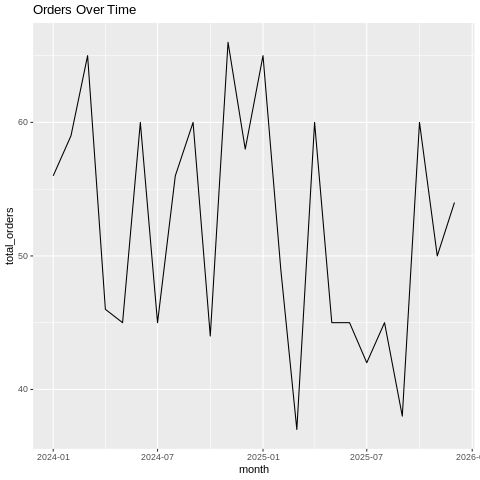

In [ ]:
%%R

orders$order_created_at <- ymd_hms(orders$order_created_at)

orders %>%
mutate(month = floor_date(order_created_at,"month")) %>%
group_by(month) %>%
summarise(total_orders = n()) %>%

ggplot(aes(month,total_orders)) +
geom_line() +
ggtitle("Orders Over Time")